In [1]:
# script to plot ignition delays compared to Metcalfe
# https://doi.org/10.1016/j.proci.2006.07.207
# See Figure 4

In [1]:
import os
import numpy as np
import pandas as pd
import cantera as ct

# import colormaps
import seaborn as sns

import matplotlib.colors as mcolors

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [30]:
# Load the experimental conditions
ignition_delay_data = '/work/westgroup/harris.se/autoscience/reaction_calculator/experiment/dib_ignition_delay.csv'
df_exp = pd.read_csv(ignition_delay_data)

# grab just the Metcalfe 2007 phi=1.0 data P=1.0 atm (table 16)
# ref_table = df_exp[df_exp['Table'] == 16]

# # grab just the Wu 2020 phi=1.0 data P=20.0 atm (table 5)
# ref_table = df_exp[df_exp['Table'] == 5]

# grab just the Metcalfe 2007 DIB phi=0.5 data P=4 atm (table 24)
ref_table = df_exp[df_exp['Table'] == 24]

# Define Initial conditions using experimental data
taus = ref_table['Time (ms)'].values.astype(float)  # ignition delay
Ts = ref_table['T (K)'].values  # Temperatures
Ps = ref_table['Pressure (bar)'].values * 1e5  # pressures in atm
phi = ref_table['Phi'].values[0]
author = ref_table['Author'].values[0]

# list of starting conditions
concentrations = []
conc_dict = {
    'DIB1(1)': ref_table['DIB1'].values[0],
    'DIB2(2)': ref_table['DIB2'].values[0],
    'O2(3)': ref_table['O2'].values[0],
    'Ar': ref_table['Ar'].values[0]
}
concentrations = [conc_dict for i in range(len(ref_table))]

In [31]:
Ps[0]

405300.0

In [3]:
exp_taus = np.array([0.07358 , 0.096065, 0.120733, 0.125421, 0.198104, 0.205796,
       0.273852, 0.325059, 0.385841])

In [4]:
working_dir = '/work/westgroup/harris.se/autoscience/reaction_calculator/delay_uncertainty/'

In [5]:
Tmin = 695  # use min and max temperature range of the data: 695K-1706K
Tmax = 1706
N = 51
temperatures = np.linspace(Tmin, Tmax, N)[::-1]


In [6]:
MAX1_base_delays = np.load('/work/westgroup/harris.se/autoscience/fuels/dib/RMG_MAX/RMG_MAX_1_20250117/table_0024/base_delays_0024.npy')
MAX2_base_delays = np.load('/scratch/harris.se/guassian_scratch/dib/RMG_MAX/RMG_MAX_2_20250119/table_0024/base_delays_0024.npy')

metcalfe_base_delays = np.load('/work/westgroup/harris.se/autoscience/fuels/dib/metcalfe/table_0024/base_delays_0024.npy')

min1_base_delays = np.load('/scratch/harris.se/guassian_scratch/dib/RMG_min/RMG_min_1_202501017/table_0024/base_delays_0024.npy')
# min2_base_delays = np.load('/scratch/harris.se/guassian_scratch/dib/RMG_min/RMG_min_2_20250118/table_0024/base_delays_0024.npy')
min2_base_delays = np.load('/work/westgroup/harris.se/autoscience/fuels/dib/RMG_min/splice_study/study1/final_splice/table_0024/base_delays_0024.npy')

# metcalfe_base_delays[metcalfe_base_delays > 0.99] = np.nan
# MAX1_base_delays[MAX1_base_delays > 0.99] = np.nan
# MAX2_base_delays[MAX2_base_delays > 0.99] = np.nan

# LOWER_THRESHOLD = 1e-10
# metcalfe_base_delays[metcalfe_base_delays < LOWER_THRESHOLD] = np.nan
# MAX1_base_delays[MAX1_base_delays < LOWER_THRESHOLD] = np.nan
# MAX2_base_delays[MAX2_base_delays < LOWER_THRESHOLD] = np.nan

In [7]:
test_min = np.load('/work/westgroup/harris.se/autoscience/fuels/dib/RMG_min/splice_study/study1/thermo39/chem_annotated.npy')

In [8]:
test_min

array([[1.17939750e-06, 9.87862760e-07, 1.17939750e-06, 1.25602979e-02,
        0.00000000e+00],
       [1.59171490e-06, 1.57017089e-06, 1.59171490e-06, 1.55955481e-02,
        0.00000000e+00],
       [2.20622467e-06, 2.07370263e-06, 2.20622467e-06, 1.85850377e-02,
        0.00000000e+00],
       [2.58521677e-06, 2.24190054e-06, 2.58521677e-06, 1.98748743e-02,
        0.00000000e+00],
       [3.96328595e-06, 3.87417176e-06, 3.96328595e-06, 2.37439868e-02,
        0.00000000e+00],
       [4.74863552e-06, 3.60406146e-06, 4.74863552e-06, 2.53985274e-02,
        0.00000000e+00],
       [7.75965855e-06, 4.35496385e-06, 7.75965855e-06, 3.02411301e-02,
        0.00000000e+00],
       [1.02923765e-05, 9.51653017e-06, 1.02923765e-05, 3.39018974e-02,
        0.00000000e+00],
       [1.29171950e-05, 1.02684989e-05, 1.29171950e-05, 3.74677293e-02,
        0.00000000e+00]])

In [53]:
min2_base_delays[:, 2]

array([1.96250951e-01, 1.17486778e-01, 6.97380837e-02, 4.21480498e-02,
       1.00095234e+00, 1.00008323e+00, 6.84410222e-01, 3.66139322e-01,
       1.95221355e-01, 1.08423954e-01, 6.47386932e-02, 4.18135910e-02,
       2.86884211e-02, 1.95487165e-02, 2.36018651e-03, 1.35175609e-03,
       8.11223787e-04, 5.05928720e-04, 3.32251089e-04, 2.21331890e-04,
       1.51579069e-04, 1.11332122e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 5.23192098e-07, 4.29822952e-07,
       3.67737992e-07, 2.87146105e-07, 1.41143863e-03, 9.79465114e-04,
       6.65459949e-04, 1.41860441e-07, 1.24498515e-07])

In [ ]:
MAX1_base_delays = np.load(
    '/work/westgroup/harris.se/autoscience/fuels/dib/RMG_MAX/DIB_20241219/table_0024/base_delays_0024.npy'
)

MAX2_base_delays = np.load(
    '/work/westgroup/harris.se/autoscience/fuels/dib/RMG_MAX/RMG_MAX_2_20250115/table_0024/base_delays_0024.npy'
)

MAX3_base_delays = np.load(
    '/work/westgroup/harris.se/autoscience/fuels/dib/RMG_MAX/RMG_MAX_3_20250115/table_0024/base_delays_0024.npy'
)

metcalfe_base_delays = np.load(
    '/work/westgroup/harris.se/autoscience/fuels/dib/metcalfe/table_0024/base_delays_0024.npy'
)


metcalfe_base_delays[metcalfe_base_delays > 0.99] = np.nan
MAX1_base_delays[MAX1_base_delays > 0.99] = np.nan
MAX2_base_delays[MAX2_base_delays > 0.99] = np.nan
MAX3_base_delays[MAX3_base_delays > 0.99] = np.nan

LOWER_THRESHOLD = 1e-10
metcalfe_base_delays[metcalfe_base_delays < LOWER_THRESHOLD] = np.nan
MAX1_base_delays[MAX1_base_delays < LOWER_THRESHOLD] = np.nan
MAX2_base_delays[MAX2_base_delays < LOWER_THRESHOLD] = np.nan
MAX3_base_delays[MAX3_base_delays < LOWER_THRESHOLD] = np.nan

In [32]:
min_splice3 = np.load('/work/westgroup/harris.se/autoscience/fuels/dib/RMG_min/splice_study/study1/manual_splice/chem_annotated.npy')

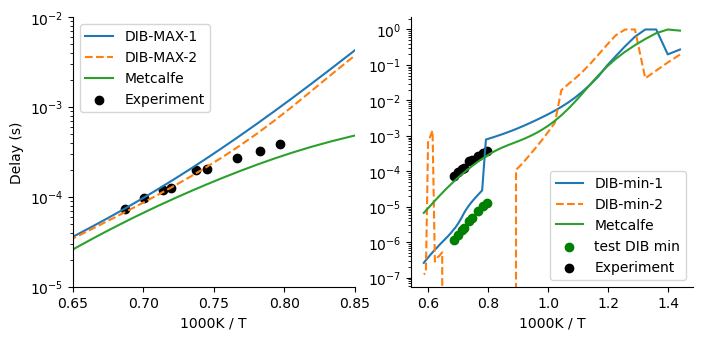

In [43]:
# get MAX
Tmin = 695  # use min and max temperature range of the data: 695K-1706K
Tmax = 1706
N = 51
temperatures = np.linspace(Tmin, Tmax, N)

# Left plot for DIB-MAX
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
plt.subplot(1, 2, 1)

# plot the ignition delay
plt.plot(1000.0 / temperatures, MAX1_base_delays[:, 2], label='DIB-MAX-1')
plt.plot(1000.0 / temperatures, MAX2_base_delays[:, 2], label='DIB-MAX-2', linestyle='dashed')
plt.plot(1000.0 / temperatures, metcalfe_base_delays[:, 2], label='Metcalfe')

plt.scatter(1000.0 / Ts, exp_taus / 1000.0, color='black', label='Experiment')

ax = plt.gca()
ax.set_yscale('log')
plt.legend()
plt.xlabel('1000K / T')
plt.ylabel('Delay (s)')
plt.legend()

plt.xlim([.65, .85])
plt.ylim([1e-5, 1e-2])
ax.spines[['right', 'top']].set_visible(False)

# ---------------------------------------------------------------
# Right plot for DIB-min
plt.subplot(1, 2, 2)
plt.plot(1000.0 / temperatures, min1_base_delays[:, 2], label='DIB-min-1')
plt.plot(1000.0 / temperatures, min2_base_delays[:, 2], label='DIB-min-2', linestyle='dashed')
plt.plot(1000.0 / temperatures, metcalfe_base_delays[:, 2], label='Metcalfe')

# plt.scatter(1000.0 / Ts, test_min[:, 0], color='red', label='test DIB min')
# plt.scatter(1000.0 / Ts, test_min[:, 2], color='green', label='test DIB min')
# plt.scatter(1000.0 / Ts, test_min[:, 3], color='cyan', label='test DIB min')

# plt.scatter(1000.0 / Ts, test_min[:, 0], color='red', label='test DIB min')
plt.scatter(1000.0 / Ts, min_splice3[:, 2], color='green', label='test DIB min')
# plt.scatter(1000.0 / Ts, test_min[:, 3], color='cyan', label='test DIB min')

plt.scatter(1000.0 / Ts, exp_taus / 1000.0, color='black', label='Experiment')

ax = plt.gca()
ax.set_yscale('log')
plt.legend()
plt.xlabel('1000K / T')
# plt.ylabel('Delay (s)')
plt.legend()

# plt.xlim([.65, .85])
# plt.ylim([1e-6, 1e-2])
ax.spines[['right', 'top']].set_visible(False)

In [ ]:
min2_base_delays = np.load('/scratch/harris.se/guassian_scratch/dib/RMG_min/DIB_20250108/table_0024/spec_delay_0024_0001.npy')

In [ ]:
min2_base_delays

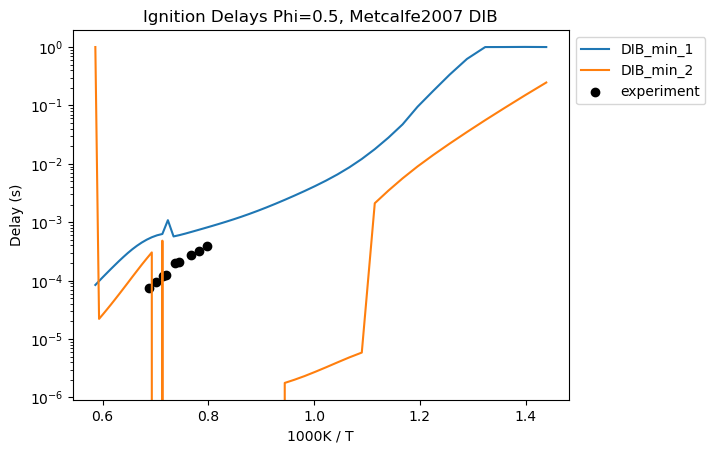

In [44]:
# # get min base delays
# min1_base_delays = np.load('/work/westgroup/harris.se/autoscience/fuels/dib/RMG_min/DIB_20241219/total_base_delays.npy')
# min1_base_delays[min1_base_delays > 0.99] = np.nan
# min2_base_delays = np.load('/scratch/harris.se/guassian_scratch/dib/RMG_min/DIB_20250108/table_0024/spec_delay_0024_0001.npy')
# min2_base_delays[min2_base_delays > 0.99] = np.nan

Tmin = 695  # use min and max temperature range of the data: 695K-1706K
Tmax = 1706
N = 51
temperatures = np.linspace(Tmin, Tmax, N)  #[::-1]

# plot the ignition delay
plt.plot(1000.0 / temperatures, min1_base_delays[:, 3], label='DIB_min_1')
plt.plot(1000.0 / temperatures, min2_base_delays[:, 3], label='DIB_min_2')

plt.scatter(1000.0 / Ts, exp_taus / 1000.0, color='black', label='experiment')

ax = plt.gca()
ax.set_yscale('log')
plt.legend()
# plt.legend(['Mechanism 174', 'Base RMG', 'Aramco', 'Experiment'])
# plt.legend(['RMG 24', 'RMG 1 week', 'Aramco', 'new calculation', 'Experiment'], loc=(1.04, 0))
plt.title(f'Ignition Delays Phi={phi}, {author} DIB')
plt.xlabel('1000K / T')
plt.ylabel('Delay (s)')
plt.savefig('table7.png')
plt.legend(bbox_to_anchor=(1, 1))


# Plot RMG-min delays

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

start_color = (1.0, 0.8, 0.0)
end_color = mcolors.hex2color(mcolors.CSS4_COLORS['forestgreen'])
aramco_color = (0.18627451, 0.48823529, 0.94117647)
colors = sns.blend_palette([start_color, end_color], n_colors=7, as_cmap=False, input='rgb')


for j, i in enumerate([4, 7, 10]):
    
    run0_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240126/table_{i:04}/base_delays_{i:04}.npy'
    run1_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240315/table_{i:04}/base_delays_{i:04}.npy'
    run2_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240403/table_{i:04}/base_delays_{i:04}.npy'
    run3_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240410/table_{i:04}/base_delays_{i:04}.npy'
    run4_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240416/table_{i:04}/base_delays_{i:04}.npy'
    run5_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240423/table_{i:04}/base_delays_{i:04}.npy'
    run6_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/butane_20240501/table_{i:04}/base_delays_{i:04}.npy'
    
    lw = np.linspace(1.0, 2.0, 7)
    lw = [1.7 for x in range(7)]
    
    run0_delay = np.load(run0_npy)
    run1_delay = np.load(run1_npy)
    run2_delay = np.load(run2_npy)
    run3_delay = np.load(run3_npy)
    run4_delay = np.load(run4_npy)
    run5_delay = np.load(run5_npy)
    run6_delay = np.load(run6_npy)

    aramco_delay_npy = os.path.join(working_dir, 'aramco', f'table_{i:04}', f'base_delays_{i:04}.npy')
    aramco_delay = np.load(aramco_delay_npy)
    
    axes[j].plot(1000.0 / temperatures, run0_delay, label='RMG-min-1', color=colors[0], linewidth=lw[0])
    axes[j].plot(1000.0 / temperatures, run1_delay, label='RMG-min-2', color=colors[1], linewidth=lw[1], linestyle='dashed')
    axes[j].plot(1000.0 / temperatures, run2_delay, label='RMG-min-3', color=colors[2], linewidth=lw[2], linestyle='dashdot')
    axes[j].plot(1000.0 / temperatures, run3_delay, label='RMG-min-4', color=colors[3], linewidth=lw[3], linestyle='solid')
    axes[j].plot(1000.0 / temperatures, run4_delay, label='RMG-min-5', color=colors[4], linewidth=lw[4], linestyle='dashed')
    axes[j].plot(1000.0 / temperatures, run5_delay, label='RMG-min-6', color=colors[5], linewidth=lw[5], linestyle='dashdot')
    axes[j].plot(1000.0 / temperatures, run6_delay, label='RMG-min-7', color=colors[6], linewidth=lw[6])
    axes[j].plot(1000.0 / temperatures, aramco_delay, label='AramcoMech3.0', color=aramco_color, linewidth=lw[6])
    axes[j].spines[['right', 'top']].set_visible(False)

    # Scale the experimental delay by the pressure
    experiment_temperatures = df_exp[df_exp['Table'] == i]['T_C'].values
    experiment_delays = df_exp[df_exp['Table'] == i]['time (ms)'].values / 1000.0
    experiment_pressures_atm = df_exp[df_exp['Table'] == i]['chamber pressure? (bar)'].values * 100000 / 101325  # convert to atm
    nominal_pressures_atm = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values
    scaled_delays = np.zeros(len(experiment_delays))
    for k in range(len(experiment_temperatures)):
        scaled_delays[k] = scale_experimental_delay(experiment_delays[k], experiment_pressures_atm[k], nominal_pressures_atm[k], experiment_temperatures[k])
        
#     axes[j].scatter(1000.0 / experiment_temperatures, experiment_delays, label='Experiment', color='black') # Without scaling
    axes[j].scatter(1000.0 / experiment_temperatures, scaled_delays, label='Experiment', color='black')  # With scaling


    axes[j].set_yscale('log')
    
    
    phi = df_exp[df_exp['Table'] == i]['phi'].values[0]
    P0 = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values[0]
    axes[j].set_title(f'$\phi={phi}$', fontsize=14)
    

axes[1].set_xlabel('1000K / T', fontsize=14)
axes[0].set_ylabel('Delay (s)', fontsize=14)
plt.sca(axes[0])
plt.legend(loc='lower right', bbox_to_anchor=(3.86, 0), fontsize=12)
plt.subplots_adjust(wspace=0.125, hspace=None)

plt.savefig('RMG-min_delays.pdf', bbox_inches='tight')


# Plot RMG-MAX Delays

In [ ]:
# read im the 12 datasets
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

P = 10
colors = [matplotlib.colormaps['viridis'].colors[:: -1][int(i / P * matplotlib.colormaps['viridis'].N)] for i in range(P)]
colors[0] = matplotlib.colormaps['viridis'].colors[:: -1][0]
colors[1] = matplotlib.colormaps['viridis'].colors[:: -1][30]
colors[2] = matplotlib.colormaps['viridis'].colors[:: -1][50]
colors[3] = matplotlib.colormaps['viridis'].colors[:: -1][90]
colors[4] = matplotlib.colormaps['viridis'].colors[:: -1][140]
colors[5] = matplotlib.colormaps['viridis'].colors[:: -1][190]
colors[6] = matplotlib.colormaps['viridis'].colors[:: -1][255]


start_color = mcolors.hex2color(mcolors.CSS4_COLORS['yellow'])  # make it yellow, but fade it 70% with alpha
start_color = (1.0, 0.8, 0.0)
end_color = mcolors.hex2color(mcolors.CSS4_COLORS['forestgreen'])
aramco_color = (0.18627451, 0.48823529, 0.94117647)
colors = sns.blend_palette([start_color, end_color], n_colors=7, as_cmap=False, input='rgb')



fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for j, i in enumerate([4, 7, 10]):
    
    run0_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/with_lib/butane_20240401/table_{i:04}/base_delays_{i:04}.npy'
    run1_npy = f'/work/westgroup/harris.se/autoscience/fuels/butane/official/with_lib/butane_20240413/table_{i:04}/base_delays_{i:04}.npy'
    
    
    
    run0_delay = np.load(run0_npy)
    run1_delay = np.load(run1_npy)

    aramco_delay_npy = os.path.join(working_dir, 'aramco', f'table_{i:04}', f'base_delays_{i:04}.npy')
    aramco_delay = np.load(aramco_delay_npy)
    
    axes[j].plot(1000.0 / temperatures, run0_delay, label='RMG-MAX-1', color=start_color, linestyle='solid')
    axes[j].plot(1000.0 / temperatures, run1_delay, label='RMG-MAX-2', color=end_color, linestyle='dashed')
    axes[j].plot(1000.0 / temperatures, aramco_delay, label='AramcoMech3.0', color=aramco_color)
    

    # Scale the experimental delay by the pressure
    experiment_temperatures = df_exp[df_exp['Table'] == i]['T_C'].values
    experiment_delays = df_exp[df_exp['Table'] == i]['time (ms)'].values / 1000.0
    experiment_pressures_atm = df_exp[df_exp['Table'] == i]['chamber pressure? (bar)'].values * 100000 / 101325  # convert to atm
    nominal_pressures_atm = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values
    scaled_delays = np.zeros(len(experiment_delays))
    for k in range(len(experiment_temperatures)):
        scaled_delays[k] = scale_experimental_delay(experiment_delays[k], experiment_pressures_atm[k], nominal_pressures_atm[k], experiment_temperatures[k])
    
    axes[j].spines[['right', 'top']].set_visible(False)
    
    
#     axes[j].scatter(1000.0 / experiment_temperatures, experiment_delays, label='Experiment', color='black')  # No scaling
    axes[j].scatter(1000.0 / experiment_temperatures, scaled_delays, label='Experiment', color='black')  # With Pressure Scaling
    axes[j].set_yscale('log')
    
    
    phi = df_exp[df_exp['Table'] == i]['phi'].values[0]
    P0 = df_exp[df_exp['Table'] == i]['nominal pressure(atm)'].values[0]
    axes[j].set_title(f'$\phi={phi}$', fontsize=14)
    

axes[1].set_xlabel('1000K / T', fontsize=14)
axes[0].set_ylabel('Delay (s)', fontsize=14)
plt.sca(axes[0])

axes[2].legend(fontsize=12)

plt.savefig('RMG-MAX_delays.pdf', bbox_inches='tight')